In [19]:
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [20]:
img = np.load(
    "/hpcstor6/scratch01/a/a.kanamarlapudi001/HQ_StudyLevel_Data/original_studylevel/images/"
    "2.25.114636451652613361168646589101988366704/"
    "2.25.290339949723526955147035839643177131600.npz"
)["data"]

In [21]:
img.shape

(3062, 2394)

In [22]:
meta = json.loads(open(
    "/hpcstor6/scratch01/a/a.kanamarlapudi001/HQ_StudyLevel_Data/original_studylevel/metadata/"
    "2.25.114636451652613361168646589101988366704/"
    "2.25.290339949723526955147035839643177131600.json"
).read())
meta

{'PatientID': 'DH53FZPEIBFT',
 'View': 'cranio-caudal',
 'WindowCenter': [2875.0, 2929.0, 2785.0],
 'WindowWidth': [900.0, 750.0, 1050.0],
 'WindowCenterWidthExplanation': ['NORMAL', 'HARDER', 'SOFTER'],
 'ImagerPixelSpacing': [0.09409090909091, 0.09409090909091],
 'ImageLaterality': 'R',
 'label': 'PreIndexCancer',
 'coords': [922.0, 992.0, 1205.0, 1276.0],
 'score': 0.19047486782073975}

In [23]:
coords = meta["coords"]
coords

[922.0, 992.0, 1205.0, 1276.0]

In [ ]:
x1, y1, x2, y2 = coords
x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)# ints needed for NumPy cropping
x1, y1, x2, y2


(922, 992, 1205, 1276)

In [25]:
# NumPy: y first, then x
lesion = img[y1:y2, x1:x2]
lesion.shape

(284, 283)

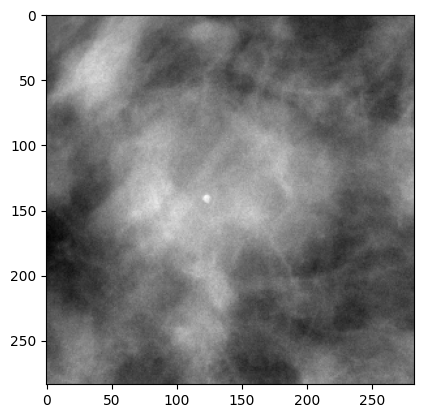

In [26]:
plt.imshow(lesion, cmap="gray")
plt.show()


In [27]:
# Rectangle needs corner, width, height
corner = (x1, y1)
width = x2 - x1
height = y2 - y1



In [28]:
box = Rectangle(corner, width, height, fill=False, edgecolor="r", lw=2)



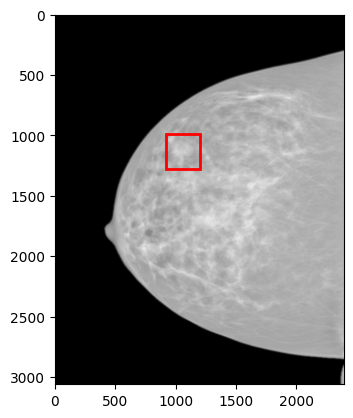

In [29]:
fig, ax = plt.subplots()
ax.imshow(img, cmap="gray")
ax.add_patch(box)
plt.show()